# Part 3 — Apps to Clone Directly (Proven Winners)

**Goal:** Find apps with massive traction AND high ratings in simple categories.  
The formula is proven. Users love it. Just build it well and it will work.

**Why this works:** Simple utility/tool apps succeed purely on execution.  
A QR scanner, unit converter, or flashlight app doesn't need innovation — it needs to be fast, clean, and free of dark patterns.

**Signals:**
- Very high installs (>1M) + high rating (>4.2) = proven formula
- Simple category (Tools, Utilities, Productivity, etc.) = replicable fast
- Low in-app purchase complexity = easy to monetize cleanly
- Many similar successful apps = validated formula, not a one-hit wonder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

TAPIVE_RELATIVE = 'data_my_copy/google-play-dataset-by-tapivedotcom.csv/google-play-dataset-by-tapivedotcom.csv'
APPS26_RELATIVE = 'data/scraped_2026/apps.csv'

def find_project_root():
    candidates = [Path().resolve()]
    p = Path().resolve()
    for _ in range(10):
        p = p.parent
        candidates.append(p)
    for c in candidates:
        if (c / TAPIVE_RELATIVE).exists():
            return c
    raise FileNotFoundError(f'Cannot find Tapive CSV. Searched: {candidates}')

ROOT = find_project_root()
TAPIVE_PATH = str(ROOT / TAPIVE_RELATIVE)
APPS_2026_PATH = str(ROOT / APPS26_RELATIVE)
print(f'Project root: {ROOT}')

print('Loading datasets...')
tap = pd.read_csv(TAPIVE_PATH, low_memory=False)
apps26 = pd.read_csv(APPS_2026_PATH, low_memory=False)
print(f'Tapive: {len(tap):,} | 2026: {len(apps26):,}')

Project root: D:\Projects\play-store-analysis-github
Loading datasets...


Tapive: 3,451,063 | 2026: 11,176


In [2]:
tap['minInstalls'] = pd.to_numeric(tap['minInstalls'], errors='coerce')
tap['score'] = pd.to_numeric(tap['score'], errors='coerce')
tap['ratings'] = pd.to_numeric(tap['ratings'], errors='coerce')
tap['reviews'] = pd.to_numeric(tap['reviews'], errors='coerce')
tap['free'] = tap['free'].astype(str).str.lower().isin(['true','1','yes'])

tap_clean = tap.dropna(subset=['genre','score','minInstalls','title']).copy()
tap_clean = tap_clean[(tap_clean['minInstalls'] > 0) & (tap_clean['score'] > 0)]

apps26['min_installs'] = pd.to_numeric(apps26['min_installs'], errors='coerce')
apps26['score'] = pd.to_numeric(apps26['score'], errors='coerce')

apps26_clean = apps26.dropna(subset=['genre','score','min_installs','title']).copy()
apps26_clean = apps26_clean[(apps26_clean['min_installs'] > 0) & (apps26_clean['score'] > 0)]

print(f'Clean: Tapive {len(tap_clean):,} | 2026 {len(apps26_clean):,}')

Clean: Tapive 445,538 | 2026 7,910


## Signal 1 — The Gold Standard: 1M+ Installs, 4.2+ Rating
These apps are the definition of proven. Users chose them and kept them.

In [3]:
gold = tap_clean[
    (tap_clean['minInstalls'] >= 1_000_000) &
    (tap_clean['score'] >= 4.2) &
    (tap_clean['free'] == True)
].copy()

# Simple categories = replicable fast
simple_cats = [
    'Tools', 'Utilities', 'Productivity', 'Personalization',
    'Finance', 'Health & Fitness', 'Lifestyle', 'Weather',
    'Travel & Local', 'Food & Drink', 'Shopping', 'Photography'
]

gold_simple = gold[gold['genre'].isin(simple_cats)].copy()

# Score = how attractive to clone (installs + rating)
gold_simple['clone_appeal'] = (
    np.log10(gold_simple['minInstalls']+1) * gold_simple['score']
)

gold_sorted = gold_simple.sort_values('clone_appeal', ascending=False)

print(f'Gold standard apps (1M+ installs, 4.2+ rating, free, simple category): {len(gold_sorted):,}')
print('\nTop 30 apps to clone directly:')
print(gold_sorted[['title','genre','minInstalls','score','ratings']].head(30).to_string(index=False))

Gold standard apps (1M+ installs, 4.2+ rating, free, simple category): 8,318

Top 30 apps to clone directly:
                         title            genre  minInstalls  score  ratings
                 Google Photos      Photography   5000000000   4.53 45986273
  Gboard - the Google Keyboard            Tools   5000000000   4.52 11458635
                 Samsung Notes     Productivity   1000000000   4.75  4155385
                        Google            Tools  10000000000   4.26 24672120
          Google Play services            Tools  10000000000   4.25 39573945
                  Google Drive     Productivity   5000000000   4.35  9422735
 Video Editor & Maker - InShot      Photography    500000000   4.83 15844335
               Files by Google            Tools   1000000000   4.63  6334107
            Microsoft OneDrive     Productivity   1000000000   4.59  3638079
                   Google Lens            Tools   1000000000   4.59  1627873
                  File Manager            To

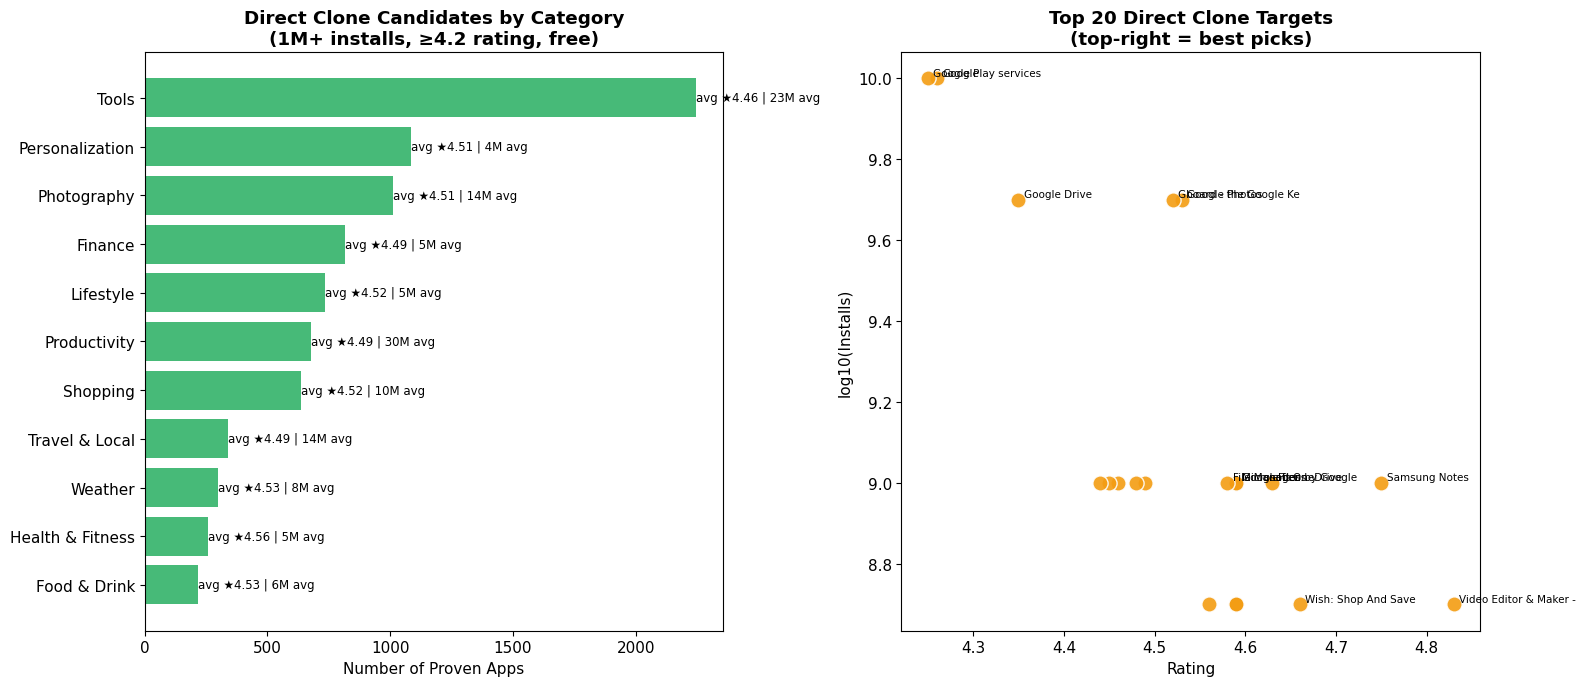

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
cat_gold = gold_simple.groupby('genre').agg(
    count=('appId','count'),
    avg_score=('score','mean'),
    avg_installs=('minInstalls','mean')
).reset_index().sort_values('count', ascending=False)

cg = cat_gold.sort_values('count')
bars = ax1.barh(cg['genre'], cg['count'], color='#27ae60', alpha=0.85)
for bar, row in zip(bars, cg.itertuples()):
    ax1.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'avg ★{row.avg_score:.2f} | {row.avg_installs/1e6:.0f}M avg',
             va='center', fontsize=8.5)
ax1.set_xlabel('Number of Proven Apps')
ax1.set_title('Direct Clone Candidates by Category\n(1M+ installs, ≥4.2 rating, free)', fontweight='bold')

ax2 = axes[1]
top_gold = gold_sorted.head(20)
ax2.scatter(top_gold['score'], np.log10(top_gold['minInstalls']+1),
            s=120, c='#f39c12', alpha=0.9, edgecolors='white', linewidth=1)
for _, row in top_gold.head(12).iterrows():
    ax2.annotate(row['title'][:22], (row['score'], np.log10(row['minInstalls']+1)),
                 fontsize=7.5, xytext=(4,2), textcoords='offset points')
ax2.set_xlabel('Rating')
ax2.set_ylabel('log10(Installs)')
ax2.set_title('Top 20 Direct Clone Targets\n(top-right = best picks)', fontweight='bold')

plt.tight_layout()
plt.savefig('p3_gold_standard.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 2 — Validated Formula: Multiple Apps Succeeding in Same Niche
When 5+ apps in a tiny niche all have 1M+ installs and 4+ stars, the category is a reliable bet — not a lucky outlier.

In [5]:
validated = tap_clean[
    (tap_clean['minInstalls'] >= 1_000_000) &
    (tap_clean['score'] >= 4.0)
].groupby('genre').agg(
    winners=('appId','count'),
    avg_score=('score','mean'),
    avg_installs=('minInstalls','mean'),
    total_installs=('minInstalls','sum')
).reset_index()

validated = validated[validated['winners'] >= 5]  # at least 5 winners in same category
validated = validated.sort_values('winners', ascending=False)

print('=== Categories with 5+ Winners (proven formula) ===')
print(validated[['genre','winners','avg_score','avg_installs','total_installs']]
      .to_string(index=False))

=== Categories with 5+ Winners (proven formula) ===
                  genre  winners  avg_score  avg_installs  total_installs
                  Tools     2958   4.372451  2.415078e+07     71438000000
                 Casual     1967   4.350519  8.346213e+06     16417000000
                 Puzzle     1804   4.436125  6.483370e+06     11696000000
          Entertainment     1735   4.360023  8.889914e+06     15424000000
             Simulation     1651   4.320036  5.738946e+06      9475000000
                 Action     1640   4.327396  1.042744e+07     17101000000
        Personalization     1347   4.429317  4.744618e+06      6391000000
            Photography     1296   4.423935  1.227932e+07     15914000000
                 Arcade     1241   4.359347  1.062530e+07     13186000000
              Education     1231   4.445946  2.787977e+06      3432000000
                Finance     1076   4.393559  4.836431e+06      5204000000
          Music & Audio     1057   4.438212  1.049858e+07   

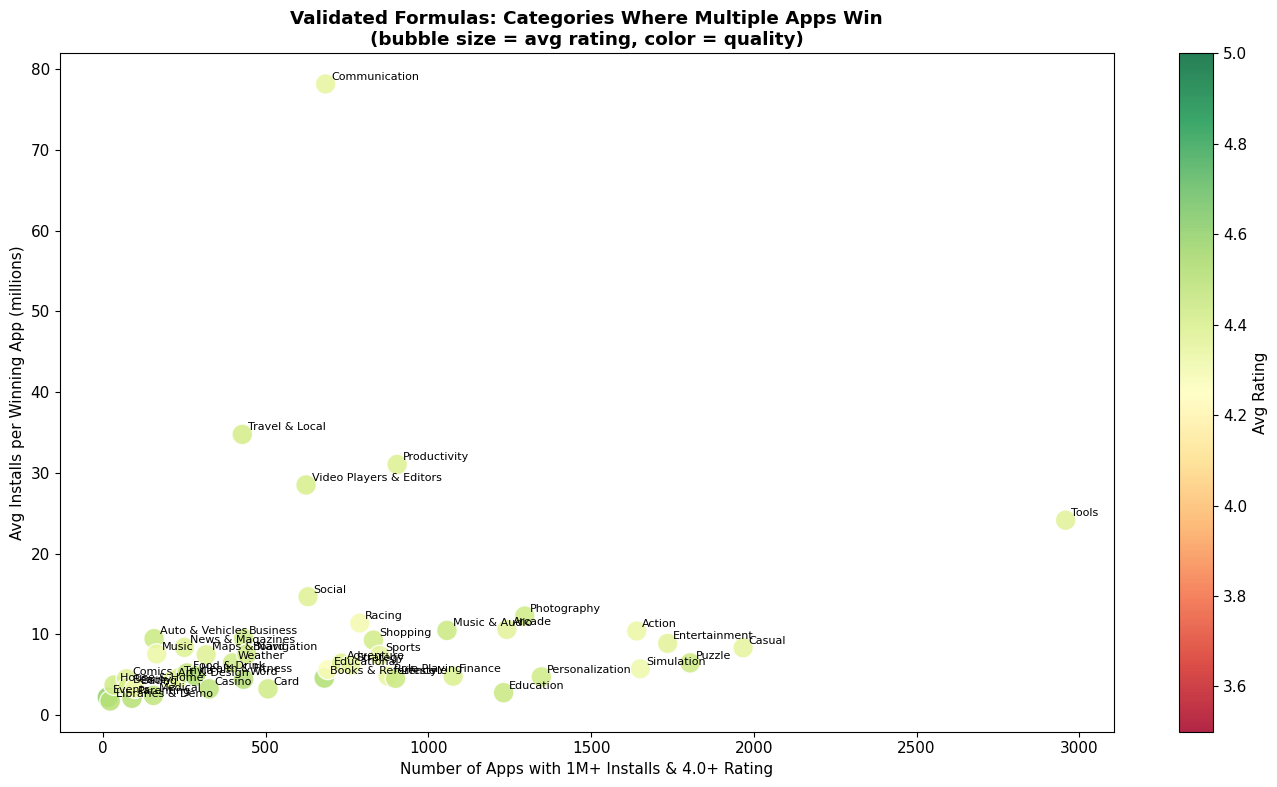

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))
val_s = validated.sort_values('winners')
scatter = ax.scatter(
    val_s['winners'],
    val_s['avg_installs'] / 1e6,
    s=val_s['avg_score'] * 50,
    c=val_s['avg_score'],
    cmap='RdYlGn',
    vmin=3.5, vmax=5.0,
    alpha=0.85,
    edgecolors='white'
)
plt.colorbar(scatter, label='Avg Rating', ax=ax)
for _, row in val_s.iterrows():
    ax.annotate(row['genre'], (row['winners'], row['avg_installs']/1e6),
                fontsize=8, xytext=(4,3), textcoords='offset points')
ax.set_xlabel('Number of Apps with 1M+ Installs & 4.0+ Rating')
ax.set_ylabel('Avg Installs per Winning App (millions)')
ax.set_title('Validated Formulas: Categories Where Multiple Apps Win\n'
             '(bubble size = avg rating, color = quality)', fontweight='bold')
plt.tight_layout()
plt.savefig('p3_validated_formulas.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 3 — App Title Pattern Analysis
Within top simple categories, what are the common app title keywords?  
These reveal the exact product formulas that are working.

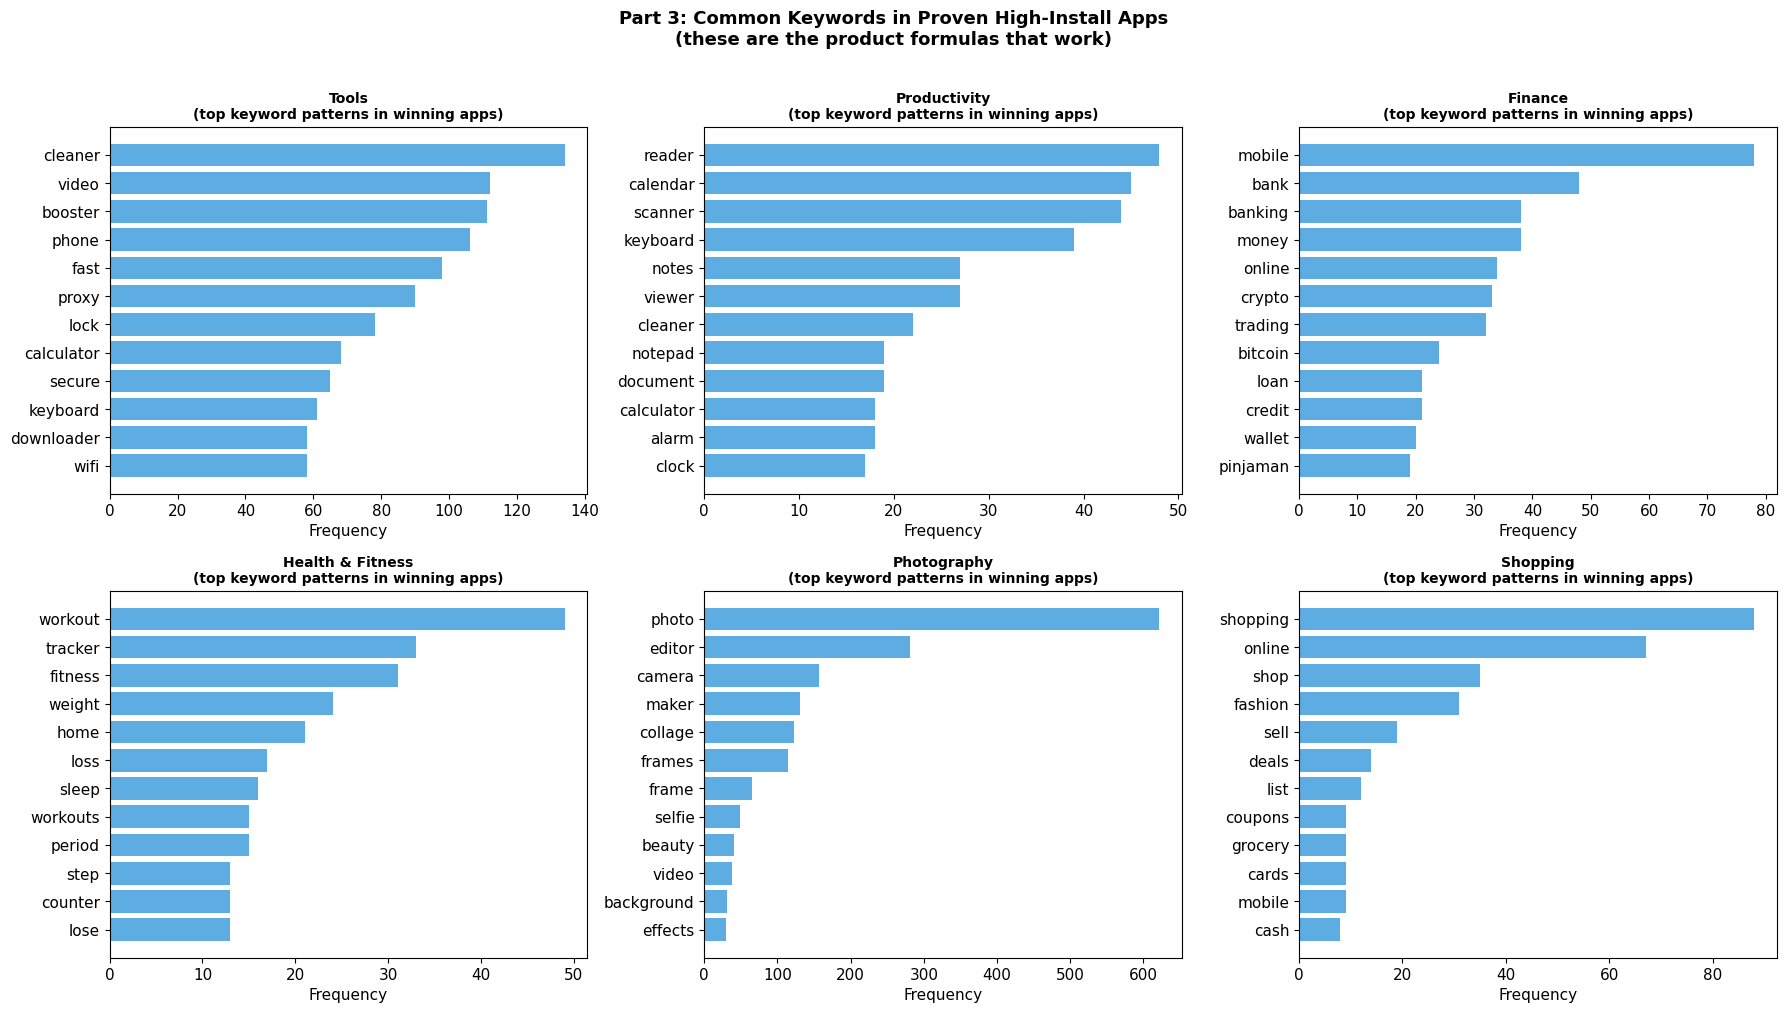

In [7]:
from collections import Counter
import re

STOP = {'app','free','pro','&','-','the','a','an','for','with','and','or','of','in','on','to',
        'best','new','your','my','by','from','all','top','easy','get','use','2024','2023','+','lite'}

top_cats = ['Tools','Productivity','Finance','Health & Fitness','Photography','Shopping']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(top_cats):
    cat_apps = gold_simple[gold_simple['genre'] == cat]
    if len(cat_apps) == 0:
        cat_apps = tap_clean[
            (tap_clean['genre'] == cat) &
            (tap_clean['minInstalls'] >= 500_000) &
            (tap_clean['score'] >= 4.0)
        ]
    
    words = []
    for title in cat_apps['title'].dropna():
        tokens = re.findall(r'[a-zA-Z]+', title.lower())
        words.extend([w for w in tokens if w not in STOP and len(w) > 3])
    
    counter = Counter(words)
    top_words = counter.most_common(12)
    
    if top_words:
        labels, counts = zip(*top_words)
        ax = axes[i]
        bars = ax.barh(labels[::-1], counts[::-1], color='#3498db', alpha=0.8)
        ax.set_title(f'{cat}\n(top keyword patterns in winning apps)', fontweight='bold', fontsize=10)
        ax.set_xlabel('Frequency')

plt.suptitle('Part 3: Common Keywords in Proven High-Install Apps\n(these are the product formulas that work)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('p3_title_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

## Final: Direct Clone Shortlist + Effort Estimate

In [8]:
# Top apps that are proven, simple, and free
final_clones_p3 = gold_sorted.copy()

# Classify complexity (rough proxy: category)
easy_cats = {'Tools', 'Utilities', 'Personalization', 'Weather'}
medium_cats = {'Productivity', 'Finance', 'Photography', 'Health & Fitness'}
hard_cats = {'Shopping', 'Travel & Local', 'Social', 'Entertainment'}

def effort(genre):
    if genre in easy_cats: return 'LOW'
    if genre in medium_cats: return 'MEDIUM'
    return 'HIGH'

final_clones_p3['build_effort'] = final_clones_p3['genre'].apply(effort)

print('='*90)
print('PART 3 FINAL: Apps to Clone Directly (Proven Winners)')
print('='*90)
print(f"{'#':<4}{'Title':<38}{'Category':<25}{'Installs':>12}{'Rating':>8}{'Effort':>10}")
print('-'*90)
for i, row in enumerate(final_clones_p3.head(30).itertuples(), 1):
    print(f"{i:<4}{row.title[:36]:<38}{row.genre:<25}"
          f"{row.minInstalls/1e6:>10.1f}M{row.score:>8.2f}{row.build_effort:>10}")

PART 3 FINAL: Apps to Clone Directly (Proven Winners)
#   Title                                 Category                     Installs  Rating    Effort
------------------------------------------------------------------------------------------
1   Google Photos                         Photography                  5000.0M    4.53    MEDIUM
2   Gboard - the Google Keyboard          Tools                        5000.0M    4.52       LOW
3   Samsung Notes                         Productivity                 1000.0M    4.75    MEDIUM
4   Google                                Tools                       10000.0M    4.26       LOW
5   Google Play services                  Tools                       10000.0M    4.25       LOW
6   Google Drive                          Productivity                 5000.0M    4.35    MEDIUM
7   Video Editor & Maker - InShot         Photography                   500.0M    4.83    MEDIUM
8   Files by Google                       Tools                        1000.0M

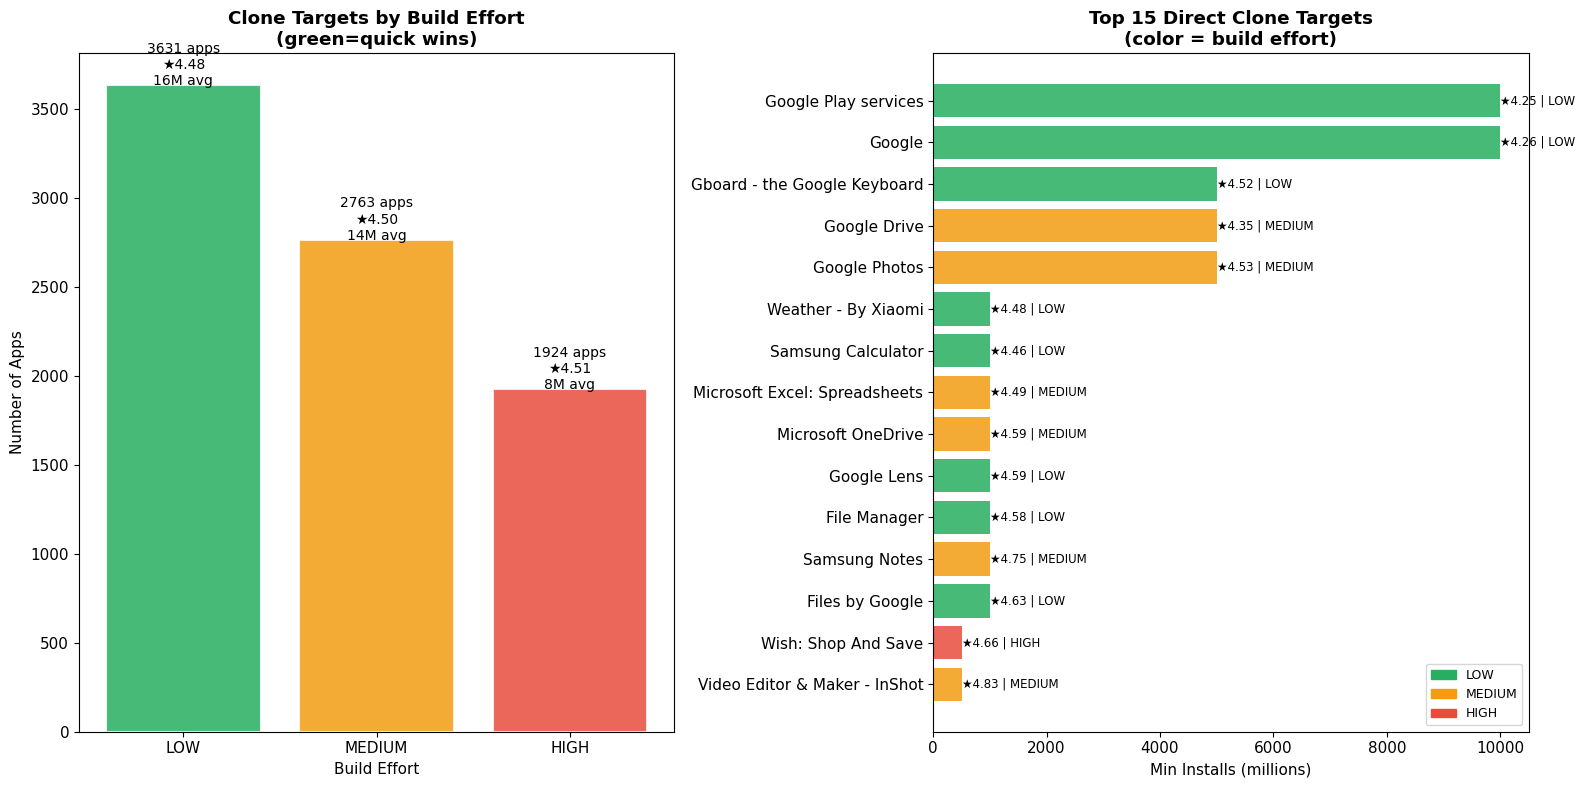

All Part 3 charts saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: by effort level
ax1 = axes[0]
effort_counts = final_clones_p3.groupby('build_effort').agg(
    count=('appId','count'),
    avg_installs=('minInstalls','mean'),
    avg_score=('score','mean')
).reset_index()

effort_order = ['LOW','MEDIUM','HIGH']
effort_colors = {'LOW':'#27ae60','MEDIUM':'#f39c12','HIGH':'#e74c3c'}
effort_counts = effort_counts.set_index('build_effort').reindex(effort_order).reset_index()
bars = ax1.bar(effort_counts['build_effort'], effort_counts['count'],
               color=[effort_colors[e] for e in effort_counts['build_effort']], alpha=0.85,
               edgecolor='white', linewidth=1.5)
for bar, row in zip(bars, effort_counts.itertuples()):
    if pd.notna(row.count):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{int(row.count)} apps\n★{row.avg_score:.2f}\n{row.avg_installs/1e6:.0f}M avg',
                 ha='center', fontsize=10)
ax1.set_xlabel('Build Effort')
ax1.set_ylabel('Number of Apps')
ax1.set_title('Clone Targets by Build Effort\n(green=quick wins)', fontweight='bold')

# Right: top 15 by installs
ax2 = axes[1]
top15 = final_clones_p3.head(15).sort_values('minInstalls')
colors_e = [effort_colors[e] for e in top15['build_effort']]
bars = ax2.barh(top15['title'].str[:30], top15['minInstalls']/1e6, color=colors_e, alpha=0.85)
for bar, row in zip(bars, top15.itertuples()):
    ax2.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'★{row.score:.2f} | {row.build_effort}',
             va='center', fontsize=8.5)
ax2.set_xlabel('Min Installs (millions)')
ax2.set_title('Top 15 Direct Clone Targets\n(color = build effort)', fontweight='bold')

# legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=e) for e, c in effort_colors.items()]
ax2.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig('p3_final_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print('All Part 3 charts saved.')

## Summary Across All 3 Parts

In [10]:
print('''
╔══════════════════════════════════════════════════════════════════════════════╗
║              APP OPPORTUNITY RESEARCH — FULL SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PART 1: BUILD ORIGINAL (category play)                                     ║
║  → Target categories where even the best apps are poor                      ║
║  → Quality gap + high demand + growing in 2026 = whitespace                 ║
║  → Requires innovation / differentiation                                    ║
║  → Highest upside, highest effort                                            ║
║                                                                              ║
║  PART 2: CLONE + IMPROVE (specific app play)                                ║
║  → Target specific apps that have users but frustrate them                  ║
║  → Fix the known pain points (ads, crashes, paywalls, stale UI)             ║
║  → Proven demand, known improvement list, faster to differentiate           ║
║  → Medium upside, medium effort                                              ║
║                                                                              ║
║  PART 3: DIRECT CLONE (formula play)                                        ║
║  → Target proven high-install high-rating simple apps                       ║
║  → Replicate the formula cleanly, monetize honestly                         ║
║  → Lowest differentiation needed, fastest to ship                           ║
║  → Lower upside, lowest effort                                               ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════════════════════╗
║              APP OPPORTUNITY RESEARCH — FULL SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PART 1: BUILD ORIGINAL (category play)                                     ║
║  → Target categories where even the best apps are poor                      ║
║  → Quality gap + high demand + growing in 2026 = whitespace                 ║
║  → Requires innovation / differentiation                                    ║
║  → Highest upside, highest effort                                            ║
║                                                                              ║
║  PART 2: CLONE + IMPROVE (specific app play)                                ║
║  → Target specific apps that have users but frustrate them                  ║
║  → Fix the known pain points (ad